> 选择 Pendulum 环境  
> 对比连续型动作输出算法： TPRO-continuous，PPO-continuous，SAC-continuous

In [9]:
import os
import sys
import random
import collections
from tqdm import tqdm
import matplotlib.pyplot as plt

try:
    base_path = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    base_path = os.path.dirname(os.getcwd())

if base_path not in sys.path:
    sys.path.insert(0, base_path)

import torch
import torch.nn.functional as F
import gymnasium as gym
import numpy as np

from src.utils import rl_utils
from src.utils.rl_utils import ReplayBuffer
from src.utils.rl_utils import plot_returns_combined
from src.utils.rl_utils import show_live_performance
from src.agents.myDQN import DQN as MyDQN
from src.agents.myActorCritic import ActorCritic as MyActorCritic
from src.agents.myTRPO import TRPO as MyTRPO
from src.agents.myTRPOcontinuous import TRPOContinuous as MyTRPOContinuous
from src.agents.myPPO import PPO as MyPPO
from src.agents.myPPOcontinuous import PPOContinuous as MyPPOContinuous
from src.agents.mySAC import SAC as MySAC
from src.agents.mySACcontinuous import SACContinuous as MySACContinuous

> 不同 seed 对于 RL 效果影响有些大，设置全局随机种子，避免这种随机性对实验判断造成干扰

In [10]:
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # 强制使用确定性算法
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    import os
    os.environ['PYTHONHASHSEED'] = str(seed)


def setup_experiment(env_name, seed=None):
    """用此函数代替 gym.make 以固定随机种子
    设置实验环境，包括随机种子和 Gym 环境。
    """
    set_seed(seed) 
    env = gym.make(env_name)
    env.action_space.seed(seed) 
    return env

SEED = 60

# 此外需要seed=SEED传入return_list = rl_utils.train_off_policy_agent

## TRPO continuous

Iteration 9: 100%|██████████| 300/300 [00:04<00:00, 69.03it/s, episode=3000, return=-336.868]


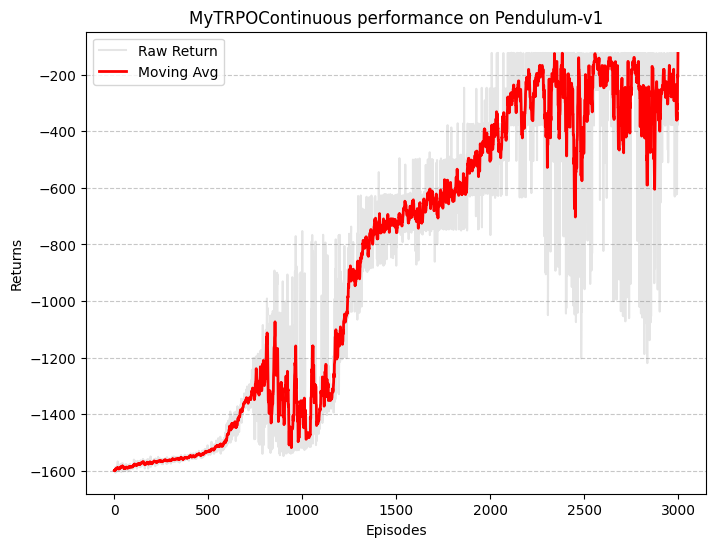

In [11]:
num_episodes = 3000  # 2000
hidden_dim = 128
gamma = 0.9
lmbda = 0.9
critic_lr = 1e-2
kl_constraint = 0.00005
alpha = 0.5
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'Pendulum-v1'
env = setup_experiment(env_name, SEED) 
# env = gym.make(env_name)

agent = MyTRPOContinuous(hidden_dim, env.observation_space, env.action_space,
                       lmbda, kl_constraint, alpha, critic_lr, gamma, device)
return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes,seed=SEED)

# 修改名称
plot_returns_combined(return_list=return_list,
                      env_name=env_name,algo_name="MyTRPOContinuous",window_size=9)

# Iteration 0: 100%|██████████| 200/200 [00:19<00:00, 10.00it/s, episode=200,
# return=-1181.390]
# Iteration 1: 100%|██████████| 200/200 [00:20<00:00,  9.98it/s, episode=400,
# return=-994.876]
# Iteration 2: 100%|██████████| 200/200 [00:20<00:00,  9.86it/s, episode=600,
# return=-888.498]
# Iteration 3: 100%|██████████| 200/200 [00:20<00:00,  9.94it/s, episode=800,
# return=-848.329]
# Iteration 4: 100%|██████████| 200/200 [00:20<00:00,  9.87it/s, episode=1000,
# return=-772.392]
# Iteration 5: 100%|██████████| 200/200 [00:20<00:00,  9.91it/s, episode=1200,
# return=-611.870]
# Iteration 6: 100%|██████████| 200/200 [00:20<00:00,  9.89it/s, episode=1400,
# return=-397.705]
# Iteration 7: 100%|██████████| 200/200 [00:20<00:00,  9.95it/s, episode=1600,
# return=-268.498]
# Iteration 8: 100%|██████████| 200/200 [00:20<00:00,  9.87it/s, episode=1800,
# return=-408.976]
# Iteration 9: 100%|██████████| 200/200 [00:19<00:00, 10.08it/s, episode=2000,
# return=-296.363]

In [12]:
# 结果可视化
show_live_performance(env_name, agent,seed=SEED, episodes=3)

回合 1 结束，得分: -125.18905220348233
回合 2 结束，得分: -127.91655401014849
回合 3 结束，得分: -378.6388019481063
可视化窗口已关闭


## PPO 连续

Iteration 9: 100%|██████████| 200/200 [00:02<00:00, 76.14it/s, episode=2000, return=-143.287]


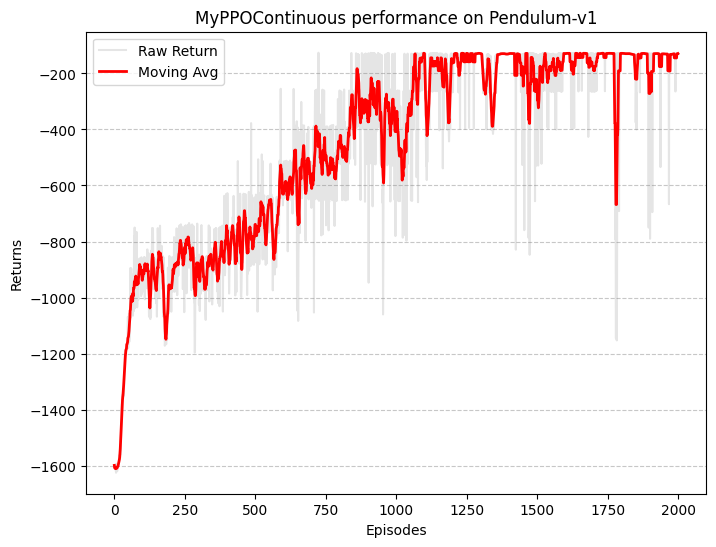

In [5]:
actor_lr = 1e-4
critic_lr = 5e-3
num_episodes = 2000
hidden_dim = 128
gamma = 0.9
lmbda = 0.9
epochs = 10
eps = 0.2
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")


env_name = 'Pendulum-v1'
env = setup_experiment(env_name, SEED) 
# env = gym.make(env_name)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]  # 连续动作空间
agent = MyPPOContinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                      lmbda, epochs, eps, gamma, device)

return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes,seed=SEED)

# 修改名称
plot_returns_combined(return_list=return_list,
                      env_name=env_name,algo_name="MyPPOContinuous",window_size=9)

# Iteration 0: 100%|██████████| 200/200 [02:15<00:00,  1.47it/s, episode=200,
# return=-984.137]
# Iteration 1: 100%|██████████| 200/200 [02:17<00:00,  1.45it/s, episode=400,
# return=-895.332]
# Iteration 2: 100%|██████████| 200/200 [02:14<00:00,  1.48it/s, episode=600,
# return=-518.916]
# Iteration 3: 100%|██████████| 200/200 [02:19<00:00,  1.44it/s, episode=800,
# return=-602.183]
# Iteration 4: 100%|██████████| 200/200 [02:17<00:00,  1.45it/s, episode=1000,
# return=-392.104]
# Iteration 5: 100%|██████████| 200/200 [02:17<00:00,  1.45it/s, episode=1200,
# return=-259.206]
# Iteration 6: 100%|██████████| 200/200 [02:17<00:00,  1.45it/s, episode=1400,
# return=-221.772]
# Iteration 7: 100%|██████████| 200/200 [02:17<00:00,  1.45it/s, episode=1600,
# return=-293.515]
# Iteration 8: 100%|██████████| 200/200 [02:17<00:00,  1.45it/s, episode=1800,
# return=-371.194]
# Iteration 9: 100%|██████████| 200/200 [02:17<00:00,  1.45it/s, episode=2000,
# return=-248.958]

In [6]:
# 结果可视化
show_live_performance(env_name, agent,seed=SEED, episodes=3)

回合 1 结束，得分: -130.20998789127276
回合 2 结束，得分: -135.3794076704564
回合 3 结束，得分: -267.2148587871863
可视化窗口已关闭


## SAC 连续

Iteration 9: 100%|██████████| 10/10 [00:02<00:00,  3.85it/s, episode=100, return=-128.406]


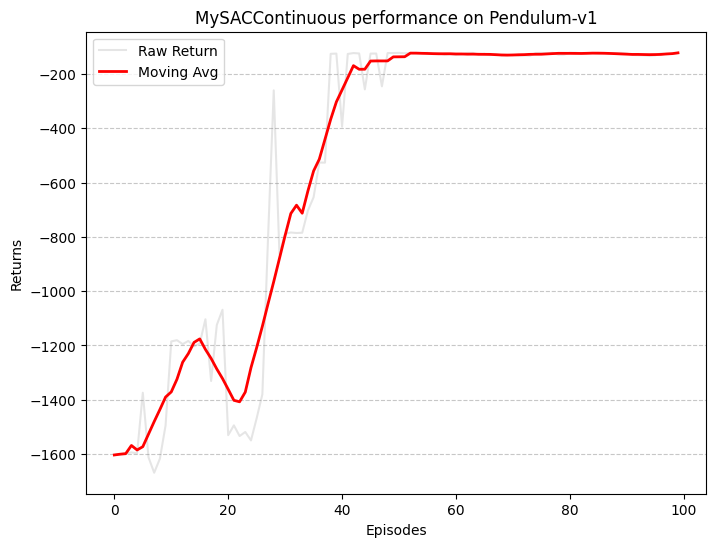

In [7]:
env_name = 'Pendulum-v1'
env = setup_experiment(env_name, SEED) 
# env = gym.make(env_name)

actor_lr = 3e-4
critic_lr = 3e-3
alpha_lr = 3e-4
num_episodes = 100
hidden_dim = 128
gamma = 0.99
tau = 0.005  # 软更新参数
buffer_size = 100000
minimal_size = 1000
batch_size = 64
target_entropy = -env.action_space.shape[0]
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0]  # 动作最大值
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
agent = MySACContinuous(state_dim, hidden_dim, action_dim, action_bound,
                      actor_lr, critic_lr, alpha_lr, target_entropy, tau,
                      gamma, device)

return_list = rl_utils.train_off_policy_agent(env, agent, num_episodes,
                                              replay_buffer, minimal_size,
                                              batch_size,seed=SEED)

# 修改名称
plot_returns_combined(return_list=return_list,
                      env_name=env_name,algo_name="MySACContinuous",window_size=9)

# Iteration 0: 100%|██████████| 10/10 [00:07<00:00,  1.35it/s, episode=10,
# return=-1534.655]
# Iteration 1: 100%|██████████| 10/10 [00:13<00:00,  1.32s/it, episode=20,
# return=-1085.715]
# Iteration 2: 100%|██████████| 10/10 [00:13<00:00,  1.38s/it, episode=30,
# return=-377.923]
# Iteration 3: 100%|██████████| 10/10 [00:13<00:00,  1.37s/it, episode=40,
# return=-284.440]
# Iteration 4: 100%|██████████| 10/10 [00:13<00:00,  1.36s/it, episode=50,
# return=-183.556]
# Iteration 5: 100%|██████████| 10/10 [00:14<00:00,  1.43s/it, episode=60,
# return=-202.841]
# Iteration 6: 100%|██████████| 10/10 [00:14<00:00,  1.41s/it, episode=70,
# return=-193.436]
# Iteration 7: 100%|██████████| 10/10 [00:14<00:00,  1.42s/it, episode=80,
# return=-131.132]
# Iteration 8: 100%|██████████| 10/10 [00:14<00:00,  1.41s/it, episode=90,
# return=-181.888]
# Iteration 9: 100%|██████████| 10/10 [00:14<00:00,  1.42s/it, episode=100,
# return=-139.574]

In [8]:
# 结果可视化
show_live_performance(env_name, agent,seed=SEED, episodes=3)

回合 1 结束，得分: -123.97948763667075
回合 2 结束，得分: -129.74333768609398
回合 3 结束，得分: -129.71063072028903
可视化窗口已关闭
